# PrePol Model Training Pipeline
## RandomForest Regression for Crime Hotspot Forecasting

This notebook trains a RandomForest regression model using the preprocessed panel data from `PrePol_panel_export.parquet`.

## 1. Import Libraries and Configuration

In [12]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# Add prepol module to path
sys.path.append(str(Path.cwd().parent))
from prepol.config import OUTPUT_DIR, RANDOM_STATE, MODEL_PREFIX

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Panel Data

In [13]:
# Load the panel data
panel_file = Path("prepol_out/PrePol_panel_export.parquet")
df_panel = pd.read_parquet(panel_file)

print(f"✓ Loaded panel data: {df_panel.shape}")
print(f"\nColumns: {list(df_panel.columns)}")
print(f"\nDate range: {df_panel['timestamp'].min()} to {df_panel['timestamp'].max()}")
print(f"\nTarget variable (y) stats:")
print(df_panel['y'].describe())

# Display sample
df_panel.head()

✓ Loaded panel data: (14468283, 11)

Columns: ['h3_cell', 'time_period', 'timestamp', 'y', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']

Date range: 2013-01-01 00:00:00 to 2016-12-31 00:00:00

Target variable (y) stats:
count    1.446828e+07
mean     8.330104e-02
std      3.378710e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.800000e+01
Name: y, dtype: float64
count    1.446828e+07
mean     8.330104e-02
std      3.378710e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.800000e+01
Name: y, dtype: float64


,h3_cell,time_period,timestamp,y,y_norm,y_lag_1,y_lag_2,y_lag_3,y_rol_3,y_rol_7,y_lag_1_vizinhos
0,89a81000003ffff,2013-01-01,2013-01-01,0,-0.163568,NaN,NaN,NaN,NaN,NaN,0
1,89a81000003ffff,2013-01-02,2013-01-02,0,-0.163568,0.0,NaN,NaN,0.000000,0.00,0
2,89a81000003ffff,2013-01-03,2013-01-03,0,-0.163568,0.0,0.0,NaN,0.000000,0.00,0
3,89a81000003ffff,2013-01-04,2013-01-04,1,5.810758,0.0,0.0,0.0,0.000000,0.00,0
4,89a81000003ffff,2013-01-05,2013-01-05,0,-0.163568,1.0,0.0,0.0,0.333333,0.25,0


## 3. Data Preparation and Feature Engineering

In [14]:
# Prepare features and target
df_model = df_panel.copy()

# Convert Period columns to ordinal integers (if any)
for col in df_model.columns:
    if pd.api.types.is_period_dtype(df_model[col]):
        print(f"Converting Period column '{col}' to ordinal...")
        df_model[col] = df_model[col].apply(lambda x: x.ordinal if pd.notna(x) else np.nan)

# Identify feature columns (exclude target and metadata)
exclude_cols = ['y', 'timestamp', 'h3_cell']
feature_cols = [col for col in df_model.columns if col not in exclude_cols]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Separate features and target
X = df_model[feature_cols]
y = df_model['y']

# Handle missing values
print(f"\nMissing values before handling:")
missing = X.isnull().sum()[X.isnull().sum() > 0]
if len(missing) > 0:
    print(missing)
else:
    print("  No missing values")

# Fill NaN with 0 for lagged features (typical for panel data)
X = X.fillna(0)

print(f"\n✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Missing values after handling: {X.isnull().sum().sum()}")

Converting Period column 'time_period' to ordinal...
Feature columns (8): ['time_period', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']
Feature columns (8): ['time_period', 'y_norm', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_rol_3', 'y_rol_7', 'y_lag_1_vizinhos']

Missing values before handling:

Missing values before handling:
y_lag_1     9903
y_lag_2    19806
y_lag_3    29709
y_rol_3     9903
y_rol_7     9903
dtype: int64
y_lag_1     9903
y_lag_2    19806
y_lag_3    29709
y_rol_3     9903
y_rol_7     9903
dtype: int64

✓ Features shape: (14468283, 8)
✓ Target shape: (14468283,)
✓ Missing values after handling: 0

✓ Features shape: (14468283, 8)
✓ Target shape: (14468283,)
✓ Missing values after handling: 0


## 4. Train-Test Split (Temporal)

In [15]:
# Check data types in features
print("Data types in the panel:")
print(df_panel.dtypes)
print("\n" + "="*60)

Data types in the panel:
h3_cell                     object
time_period              period[D]
timestamp           datetime64[ns]
y                            int32
y_norm                     float64
y_lag_1                    float64
y_lag_2                    float64
y_lag_3                    float64
y_rol_3                    float64
y_rol_7                    float64
y_lag_1_vizinhos             int64
dtype: object



In [16]:
# Use temporal split to respect time series nature
# Sort by timestamp to ensure temporal ordering
df_model = df_model.sort_values('timestamp').reset_index(drop=True)
X = df_model[feature_cols].fillna(0)
y = df_model['y']

# Use 80-20 split maintaining temporal order
split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

train_dates = df_model['timestamp'].iloc[:split_idx]
test_dates = df_model['timestamp'].iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"  Date range: {train_dates.min()} to {train_dates.max()}")
print(f"  Target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  Date range: {test_dates.min()} to {test_dates.max()}")
print(f"  Target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Training set: 11574626 samples
  Date range: 2013-01-01 00:00:00 to 2016-03-14 00:00:00
  Target mean: 0.08, std: 0.31

Test set: 2893657 samples
  Date range: 2016-03-14 00:00:00 to 2016-12-31 00:00:00
  Target mean: 0.11, std: 0.42
  Date range: 2016-03-14 00:00:00 to 2016-12-31 00:00:00
  Target mean: 0.11, std: 0.42


## 5. Train RandomForest Regression Model

In [17]:
# Initialize RandomForest Regressor
print("Training RandomForest Regression model...")
print("-" * 60)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Train the model
rf_model.fit(X_train, y_train)

print("\n✓ Model training complete!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Training RandomForest Regression model...
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.8min



✓ Model training complete!
Number of trees: 100
Number of features: 8


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.2min finished


## 6. Model Evaluation

In [18]:
# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    """Calculate and display regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE with handling for zero values
    mask = y_true != 0
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = np.nan
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  MAE (Mean Absolute Error):  {mae:.4f}")
    print(f"  MSE (Mean Squared Error):   {mse:.4f}")
    print(f"  RMSE (Root MSE):            {rmse:.4f}")
    print(f"  R² Score:                   {r2:.4f}")
    print(f"  MAPE:                       {mape:.2f}%")
    
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2, 'mape': mape}

print("=" * 60)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 60)

train_metrics = calculate_metrics(y_train, y_train_pred, "TRAINING SET")
test_metrics = calculate_metrics(y_test, y_test_pred, "TEST SET")

print("\n" + "=" * 60)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    7.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    7.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.8s finished
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.8s finished


MODEL PERFORMANCE EVALUATION

TRAINING SET Metrics:
  MAE (Mean Absolute Error):  0.0098
  MSE (Mean Squared Error):   0.0067
  RMSE (Root MSE):            0.0817
  R² Score:                   0.9325
  MAPE:                       9.85%

TEST SET Metrics:
  MAE (Mean Absolute Error):  0.0182
  MSE (Mean Squared Error):   0.0154
  RMSE (Root MSE):            0.1243
  R² Score:                   0.9110
  MAPE:                       12.53%


TRAINING SET Metrics:
  MAE (Mean Absolute Error):  0.0098
  MSE (Mean Squared Error):   0.0067
  RMSE (Root MSE):            0.0817
  R² Score:                   0.9325
  MAPE:                       9.85%

TEST SET Metrics:
  MAE (Mean Absolute Error):  0.0182
  MSE (Mean Squared Error):   0.0154
  RMSE (Root MSE):            0.1243
  R² Score:                   0.9110
  MAPE:                       12.53%



## 7. Feature Importance Analysis

Top 10 Most Important Features:
         feature  importance
          y_norm    0.884264
         y_rol_7    0.048152
y_lag_1_vizinhos    0.026770
         y_rol_3    0.021787
         y_lag_1    0.006580
         y_lag_2    0.004259
     time_period    0.004098
         y_lag_3    0.004089


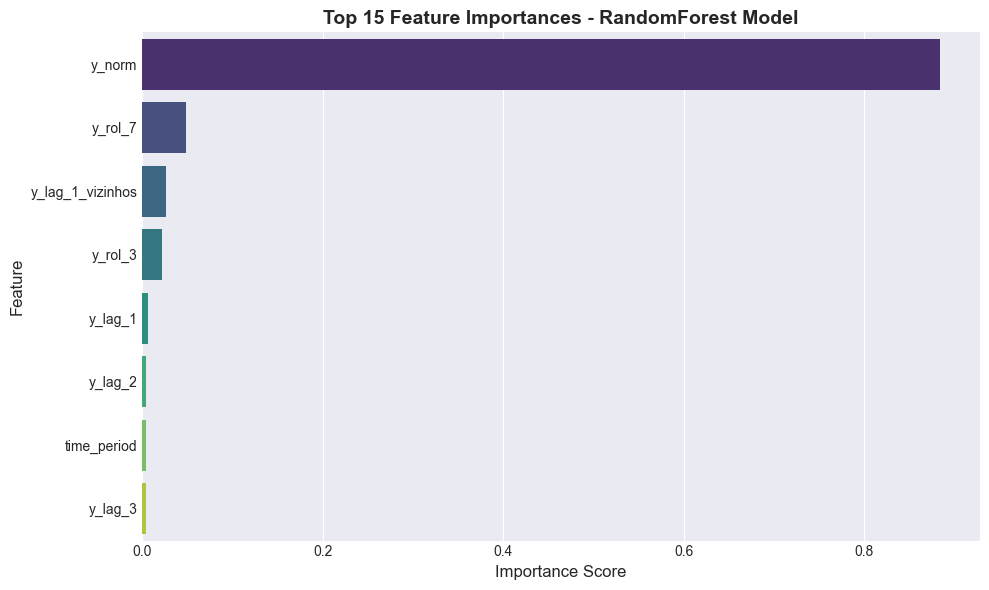

,feature,importance
1,y_norm,0.884264
6,y_rol_7,0.048152
7,y_lag_1_vizinhos,0.026770
5,y_rol_3,0.021787
2,y_lag_1,0.006580
3,y_lag_2,0.004259
0,time_period,0.004098
4,y_lag_3,0.004089


In [19]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_n = 15
sns.barplot(
    data=feature_importance.head(top_n),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title(f'Top {top_n} Feature Importances - RandomForest Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

feature_importance.head(20)

## 8. Prediction Visualization

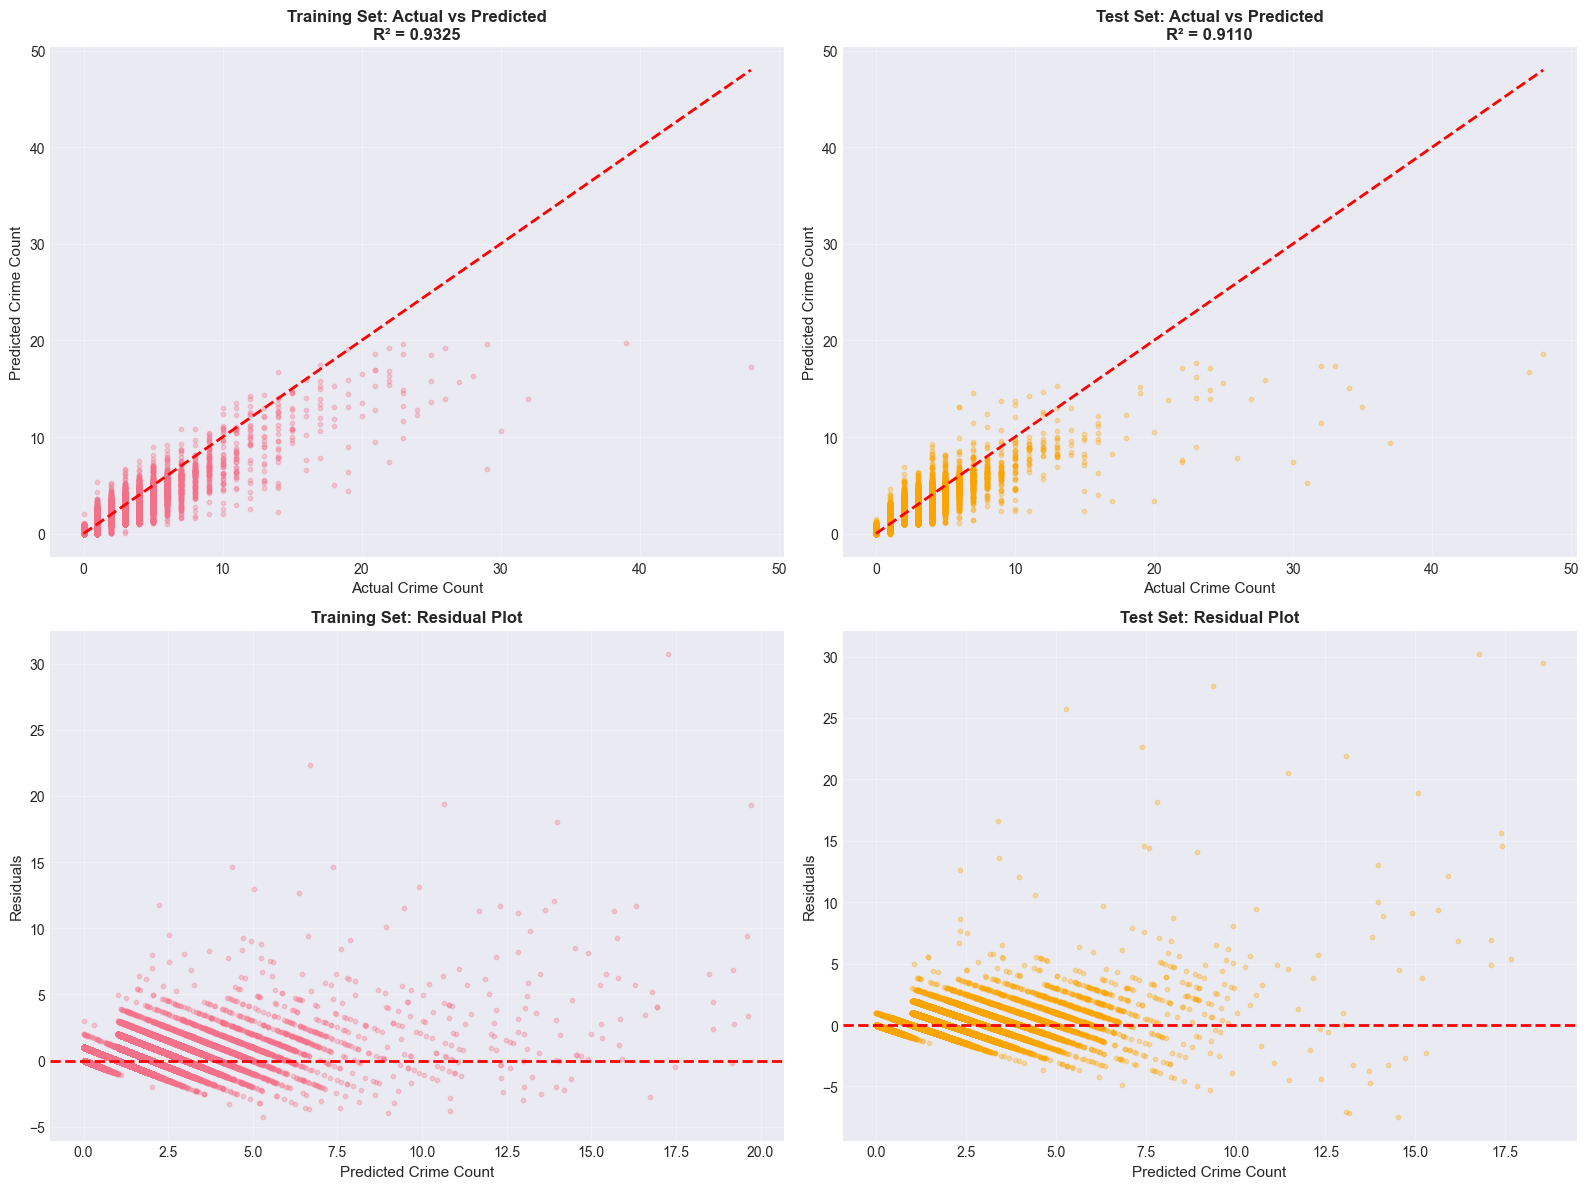

In [20]:
# Create prediction comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted - Training
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Crime Count', fontsize=11)
axes[0, 0].set_ylabel('Predicted Crime Count', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_metrics["r2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted - Test
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Crime Count', fontsize=11)
axes[0, 1].set_ylabel('Predicted Crime Count', fontsize=11)
axes[0, 1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_metrics["r2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals - Training
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Crime Count', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Training Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals - Test
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.3, s=10, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Crime Count', fontsize=11)
axes[1, 1].set_ylabel('Residuals', fontsize=11)
axes[1, 1].set_title('Test Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Model and Metadata

In [21]:
# Generate timestamp for model versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Define output paths (parent directory)
model_dir = Path.cwd().parent / "model"
model_dir.mkdir(exist_ok=True)

model_filename = f"{MODEL_PREFIX}_{timestamp}.joblib"
meta_filename = f"{MODEL_PREFIX}_meta_{timestamp}.json"

model_path = model_dir / model_filename
meta_path = model_dir / meta_filename

# Save the model
joblib.dump(rf_model, model_path)
print(f"✓ Model saved: {model_path}")

# Prepare metadata
metadata = {
    "model_type": "RandomForestRegressor",
    "timestamp": timestamp,
    "training_date": datetime.now().isoformat(),
    "model_params": rf_model.get_params(),
    "feature_columns": feature_cols,
    "n_features": len(feature_cols),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
    "train_date_range": {
        "start": str(train_dates.min()),
        "end": str(train_dates.max())
    },
    "test_date_range": {
        "start": str(test_dates.min()),
        "end": str(test_dates.max())
    },
    "metrics": {
        "train": {k: float(v) if not pd.isna(v) else None for k, v in train_metrics.items()},
        "test": {k: float(v) if not pd.isna(v) else None for k, v in test_metrics.items()}
    },
    "top_features": feature_importance.head(10)[['feature', 'importance']].to_dict('records')
}

# Save metadata
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
    
print(f"✓ Metadata saved: {meta_path}")
print("\n" + "=" * 60)
print("MODEL TRAINING PIPELINE COMPLETE")
print("=" * 60)

✓ Model saved: d:\BackupSupremo\Work\prepol-project\model\rf_crime_model_20251119_1852.joblib
✓ Metadata saved: d:\BackupSupremo\Work\prepol-project\model\rf_crime_model_meta_20251119_1852.json

MODEL TRAINING PIPELINE COMPLETE


## 10. Summary Report

In [22]:
# Print comprehensive summary
print("\n" + "=" * 70)
print(" " * 15 + "PREPOL MODEL TRAINING SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset Information:")
print(f"   • Total samples: {len(df_model):,}")
print(f"   • Training samples: {len(X_train):,} ({len(X_train)/len(df_model)*100:.1f}%)")
print(f"   • Test samples: {len(X_test):,} ({len(X_test)/len(df_model)*100:.1f}%)")
print(f"   • Number of features: {len(feature_cols)}")
print(f"   • Date range: {df_model['timestamp'].min()} to {df_model['timestamp'].max()}")

print(f"\n🌲 Model Configuration:")
print(f"   • Algorithm: RandomForest Regression")
print(f"   • Number of trees: {rf_model.n_estimators}")
print(f"   • Max depth: {rf_model.max_depth}")
print(f"   • Min samples split: {rf_model.min_samples_split}")
print(f"   • Min samples leaf: {rf_model.min_samples_leaf}")

print(f"\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"   • R² Score: {train_metrics['r2']:.4f}")
print(f"   • MAE: {train_metrics['mae']:.4f}")
print(f"   • RMSE: {train_metrics['rmse']:.4f}")
print(f"   • MAPE: {train_metrics['mape']:.2f}%")

print(f"\n   Test Set:")
print(f"   • R² Score: {test_metrics['r2']:.4f}")
print(f"   • MAE: {test_metrics['mae']:.4f}")
print(f"   • RMSE: {test_metrics['rmse']:.4f}")
print(f"   • MAPE: {test_metrics['mape']:.2f}%")

print(f"\n🎯 Top 5 Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\n💾 Saved Files:")
print(f"   • Model: {model_path.name}")
print(f"   • Metadata: {meta_path.name}")
print(f"   • Location: {model_dir}")

print("\n" + "=" * 70)
print("✓ Training pipeline completed successfully!")
print("=" * 70)


               PREPOL MODEL TRAINING SUMMARY

📊 Dataset Information:
   • Total samples: 14,468,283
   • Training samples: 11,574,626 (80.0%)
   • Test samples: 2,893,657 (20.0%)
   • Number of features: 8
   • Date range: 2013-01-01 00:00:00 to 2016-12-31 00:00:00

🌲 Model Configuration:
   • Algorithm: RandomForest Regression
   • Number of trees: 100
   • Max depth: 15
   • Min samples split: 10
   • Min samples leaf: 5

📈 Performance Metrics:

   Training Set:
   • R² Score: 0.9325
   • MAE: 0.0098
   • RMSE: 0.0817
   • MAPE: 9.85%

   Test Set:
   • R² Score: 0.9110
   • MAE: 0.0182
   • RMSE: 0.1243
   • MAPE: 12.53%

🎯 Top 5 Important Features:
   2. y_norm: 0.8843
   7. y_rol_7: 0.0482
   8. y_lag_1_vizinhos: 0.0268
   6. y_rol_3: 0.0218
   3. y_lag_1: 0.0066

💾 Saved Files:
   • Model: rf_crime_model_20251119_1852.joblib
   • Metadata: rf_crime_model_meta_20251119_1852.json
   • Location: d:\BackupSupremo\Work\prepol-project\model

✓ Training pipeline completed successfully!